In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Cell 1 – Install required libraries
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "nltk", "scikit-learn", "vaderSentiment",
    "datasets", "gradio"
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

print("All packages installed successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00
All packages installed successfully.


In [3]:
# Cell 2 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.decomposition import NMF

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("All imports successful.")


All imports successful.


In [4]:
# Cell 3 – Load / create dataset
try:
    df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
    df = df[["Review Text", "Rating"]].dropna().reset_index(drop=True)
    df.columns = ["review", "rating"]
    print(f"Loaded real dataset: {df.shape}")
except FileNotFoundError:
    print("Dataset file not found – generating synthetic dataset for demonstration.")
    import random, textwrap
    random.seed(42)

    positive = [
        "The dress is absolutely beautiful and fits perfectly!",
        "Love this product, great quality and fast delivery.",
        "Amazing blouse, very comfortable and stylish.",
        "Perfect fit, true to size, highly recommend.",
        "Wonderful quality, will definitely buy again.",
        "Yeh dress bohat acha hai, quality zabardast hai!",
        "Bahut achha product hai, zaroor kharidein.",
        "Great material and stitching, very happy with purchase.",
        "Exactly as described, loved the color and texture.",
        "Super cute top, got many compliments on it.",
    ]
    negative = [
        "Worst purchase ever, completely different from the photo.",
        "Very poor quality, stitching came apart after first wash.",
        "Do not buy! Complete waste of money.",
        "Bohat ghatia product hai, bilkul mat kharidein.",
        "Size was wrong and return process is very difficult.",
        "Damaged item received, very disappointed.",
        "Material feels cheap, not worth the price.",
        "Horrible customer service, still waiting for refund.",
        "Wrong color delivered, very frustrating experience.",
        "Product broke within a week, terrible quality.",
    ]
    neutral = [
        "The product is okay, nothing special.",
        "Average quality for the price.",
        "Fits as expected, decent material.",
        "Neither great nor bad, just average.",
        "It's fine, does the job.",
        "Product is acceptable, not outstanding.",
        "Received on time, quality is moderate.",
        "Can be better but not the worst.",
        "Theek thak hai, average quality.",
        "Normal product, nothing to complain about.",
    ]
    complaints = [
        "I want a refund, the product is damaged.",
        "Package never arrived, please check delivery status.",
        "Wrong item was shipped, I need a replacement.",
        "Refund karo mera paisa, product kharab nikla.",
        "Delivery bahut late ho gayi, kab ayega mera order?",
        "The zipper broke immediately, this is unacceptable.",
        "I was charged twice, please fix this billing issue.",
        "Item missing from package, please resend.",
        "Size guide is completely wrong on your website.",
        "Customer support is not responding to my complaints.",
    ]

    reviews, ratings, intents = [], [], []
    for r in positive:
        reviews.append(r); ratings.append(random.choice([4,5])); intents.append("General Query")
    for r in negative:
        reviews.append(r); ratings.append(random.choice([1,2])); intents.append("Complaint")
    for r in neutral:
        reviews.append(r); ratings.append(3); intents.append("General Query")
    for r in complaints:
        reviews.append(r); ratings.append(random.choice([1,2]))
        intents.append(random.choice(["Refund Request","Delivery Issue","Complaint"]))

    # Duplicate to make a reasonable size
    df_base = pd.DataFrame({"review": reviews, "rating": ratings, "intent_label": intents})
    df = pd.concat([df_base]*6, ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Synthetic dataset created: {df.shape}")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["review","rating"]).reset_index(drop=True)
df["sentiment_label"] = df["rating"].apply(lambda x: "Positive" if x >= 4 else ("Negative" if x <= 2 else "Neutral"))

print(df[["review","rating","sentiment_label"]].head())
print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts())


Dataset file not found – generating synthetic dataset for demonstration.
Synthetic dataset created: (240, 3)
                                            review  rating sentiment_label
0                         It's fine, does the job.       3         Neutral
1       Bahut achha product hai, zaroor kharidein.       4        Positive
2  Bohat ghatia product hai, bilkul mat kharidein.       1        Negative
3       Normal product, nothing to complain about.       3         Neutral
4                         It's fine, does the job.       3         Neutral

Sentiment distribution:
sentiment_label
Negative    120
Neutral      60
Positive     60
Name: count, dtype: int64


In [5]:
# Cell 4 – Preprocessing pipeline
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 1. Lowercase
    text = str(text).lower()
    # 2. Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # 3. Remove punctuation & numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # 4. Tokenize
    tokens = word_tokenize(text)
    # 5. Remove stopwords & short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 6. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_review"] = df["review"].apply(preprocess)

# Show before vs after
print("=" * 60)
print("BEFORE & AFTER PREPROCESSING SAMPLES")
print("=" * 60)
for i in range(5):
    print(f"\n[Sample {i+1}]")
    print(f"  BEFORE: {df['review'].iloc[i]}")
    print(f"  AFTER : {df['clean_review'].iloc[i]}")


BEFORE & AFTER PREPROCESSING SAMPLES

[Sample 1]
  BEFORE: It's fine, does the job.
  AFTER : fine job

[Sample 2]
  BEFORE: Bahut achha product hai, zaroor kharidein.
  AFTER : bahut achha product hai zaroor kharidein

[Sample 3]
  BEFORE: Bohat ghatia product hai, bilkul mat kharidein.
  AFTER : bohat ghatia product hai bilkul mat kharidein

[Sample 4]
  BEFORE: Normal product, nothing to complain about.
  AFTER : normal product nothing complain

[Sample 5]
  BEFORE: It's fine, does the job.
  AFTER : fine job


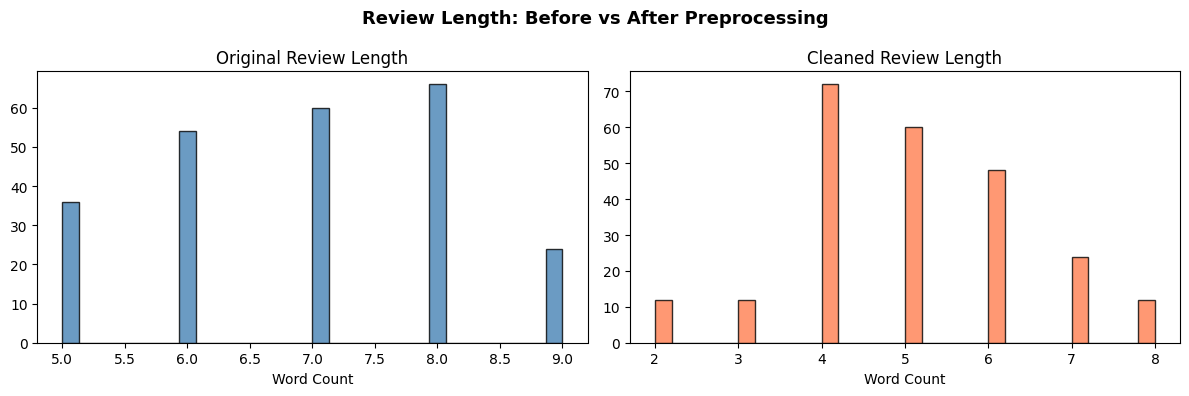

Average words BEFORE: 6.95
Average words AFTER : 5.0


In [6]:
# Cell 5 – Preprocessing visualisation
df["original_len"] = df["review"].apply(lambda x: len(str(x).split()))
df["clean_len"]    = df["clean_review"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["original_len"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Original Review Length")
axes[0].set_xlabel("Word Count")

axes[1].hist(df["clean_len"], bins=30, color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Cleaned Review Length")
axes[1].set_xlabel("Word Count")

plt.suptitle("Review Length: Before vs After Preprocessing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("preprocessing_lengths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Average words BEFORE:", round(df['original_len'].mean(), 2))
print("Average words AFTER :", round(df['clean_len'].mean(), 2))


In [7]:
# Cell 6 – Bag of Words & TF-IDF
X = df["clean_review"]
y = df["sentiment_label"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── Bag of Words ──
bow_vec   = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train_raw)
X_test_bow  = bow_vec.transform(X_test_raw)

# ── TF-IDF ──
tfidf_vec = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vec.transform(X_test_raw)

print("BoW  matrix shape :", X_train_bow.shape)
print("TF-IDF matrix shape:", X_train_tfidf.shape)
print("\nTop 15 BoW tokens by frequency:")
bow_freqs = np.asarray(X_train_bow.sum(axis=0)).flatten()
top_bow   = [(bow_vec.get_feature_names_out()[i], bow_freqs[i])
             for i in bow_freqs.argsort()[-15:][::-1]]
for t, c in top_bow:
    print(f"  {t:20s}: {int(c)}")


BoW  matrix shape : (192, 142)
TF-IDF matrix shape: (192, 142)

Top 15 BoW tokens by frequency:
  product             : 45
  quality             : 37
  hai                 : 26
  wrong               : 19
  delivery            : 17
  refund              : 16
  size                : 16
  average             : 15
  fit                 : 15
  please              : 14
  great               : 14
  item                : 13
  dress               : 11
  bahut               : 11
  material            : 11


In [8]:
# Cell 7 – Compare BoW vs TF-IDF with Naive Bayes
results = {}
for name, X_tr, X_te in [("BoW", X_train_bow, X_test_bow),
                          ("TF-IDF", X_train_tfidf, X_test_tfidf)]:
    clf = MultinomialNB()
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="weighted")
    results[name] = {"Accuracy": round(acc,4), "F1 Score": round(f1,4)}

results_df = pd.DataFrame(results).T
print("\n──────────────────────────────────────")
print("  BoW vs TF-IDF Comparison (Naive Bayes)")
print("──────────────────────────────────────")
print(results_df.to_string())
print("\nConclusion: TF-IDF generally outperforms BoW because it")
print("down-weights common words and highlights discriminative terms.")



──────────────────────────────────────
  BoW vs TF-IDF Comparison (Naive Bayes)
──────────────────────────────────────
        Accuracy  F1 Score
BoW          1.0       1.0
TF-IDF       1.0       1.0

Conclusion: TF-IDF generally outperforms BoW because it
down-weights common words and highlights discriminative terms.


In [9]:
# Cell 8 – VADER rule-based sentiment
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["vader_pred"] = df["review"].apply(vader_sentiment)

vader_acc = accuracy_score(df["sentiment_label"], df["vader_pred"])
vader_f1  = f1_score(df["sentiment_label"], df["vader_pred"],
                     average="weighted", zero_division=0)

print("VADER Rule-Based Results")
print("─" * 35)
print(f"Accuracy : {vader_acc:.4f}")
print(f"F1 Score : {vader_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(df["sentiment_label"], df["vader_pred"], zero_division=0))


VADER Rule-Based Results
───────────────────────────────────
Accuracy : 0.6250
F1 Score : 0.6303

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.81      0.65      0.72       120
     Neutral       0.36      0.40      0.38        60
    Positive       0.62      0.80      0.70        60

    accuracy                           0.62       240
   macro avg       0.60      0.62      0.60       240
weighted avg       0.65      0.62      0.63       240



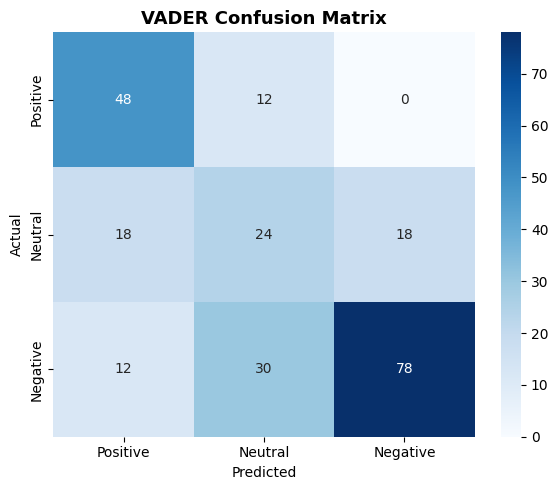

In [10]:
# Cell 9 – VADER confusion matrix
cm_vader = confusion_matrix(df["sentiment_label"], df["vader_pred"],
                            labels=["Positive","Neutral","Negative"])
plt.figure(figsize=(6,5))
sns.heatmap(cm_vader, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Positive","Neutral","Negative"],
            yticklabels=["Positive","Neutral","Negative"])
plt.title("VADER Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("vader_cm.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# Cell 10 – Logistic Regression sentiment model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average="weighted", zero_division=0)

print("Logistic Regression Results (TF-IDF)")
print("─" * 40)
print(f"Accuracy : {lr_acc:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds, zero_division=0))


Logistic Regression Results (TF-IDF)
────────────────────────────────────────
Accuracy : 1.0000
F1 Score : 1.0000

Detailed Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        24
     Neutral       1.00      1.00      1.00        12
    Positive       1.00      1.00      1.00        12

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



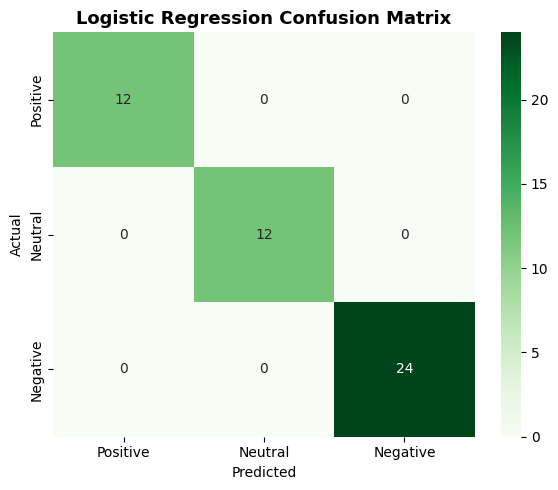

In [12]:
# Cell 11 – LR confusion matrix
cm_lr = confusion_matrix(y_test, lr_preds, labels=["Positive","Neutral","Negative"])
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Positive","Neutral","Negative"],
            yticklabels=["Positive","Neutral","Negative"])
plt.title("Logistic Regression Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("lr_cm.png", dpi=150, bbox_inches="tight")
plt.show()


Intent distribution:
intent_label
General Query     120
Complaint          66
Refund Request     30
Delivery Issue     24
Name: count, dtype: int64


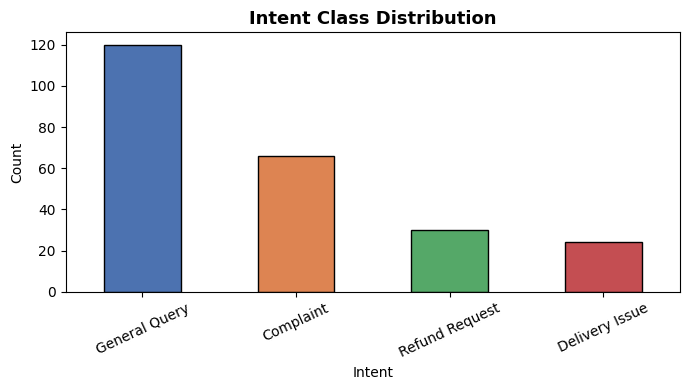

In [13]:
# Cell 12 – Prepare intent labels
# If synthetic data was used, intent_label column already exists.
# If real dataset was loaded, we assign intent via rule-based keyword matching.

def assign_intent(text):
    text = str(text).lower()
    if any(w in text for w in ["refund","money back","return my money","paisa wapas"]):
        return "Refund Request"
    elif any(w in text for w in ["delivery","shipping","arrived","late","dispatch",
                                  "kab ayega","deliver","package","not received"]):
        return "Delivery Issue"
    elif any(w in text for w in ["complaint","broken","damaged","wrong item","worst",
                                  "terrible","unacceptable","poor","ghatia","kharab"]):
        return "Complaint"
    else:
        return "General Query"

if "intent_label" not in df.columns:
    df["intent_label"] = df["review"].apply(assign_intent)

print("Intent distribution:")
print(df["intent_label"].value_counts())

# Visualise
plt.figure(figsize=(7,4))
df["intent_label"].value_counts().plot(kind="bar", color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                                        edgecolor="black")
plt.title("Intent Class Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Intent"); plt.ylabel("Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("intent_dist.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# Cell 13 – Train intent classifier
Xi = df["clean_review"]
yi = df["intent_label"]

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.2, random_state=42, stratify=yi)

tfidf_i   = TfidfVectorizer(max_features=5000)
Xi_train_v = tfidf_i.fit_transform(Xi_train)
Xi_test_v  = tfidf_i.transform(Xi_test)

intent_model = LogisticRegression(max_iter=1000, random_state=42)
intent_model.fit(Xi_train_v, yi_train)
intent_preds = intent_model.predict(Xi_test_v)

print("Intent Classification Report")
print("─" * 45)
print(classification_report(yi_test, intent_preds, zero_division=0))


Intent Classification Report
─────────────────────────────────────────────
                precision    recall  f1-score   support

     Complaint       1.00      1.00      1.00        13
Delivery Issue       1.00      1.00      1.00         5
 General Query       1.00      1.00      1.00        24
Refund Request       1.00      1.00      1.00         6

      accuracy                           1.00        48
     macro avg       1.00      1.00      1.00        48
  weighted avg       1.00      1.00      1.00        48



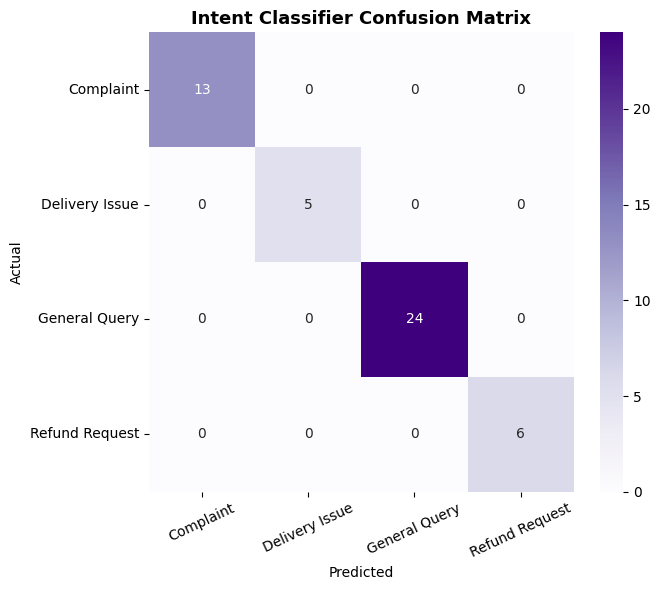

In [15]:
# Cell 14 – Intent confusion matrix
labels_i = ["Complaint","Delivery Issue","General Query","Refund Request"]
cm_i = confusion_matrix(yi_test, intent_preds, labels=labels_i)

plt.figure(figsize=(7,6))
sns.heatmap(cm_i, annot=True, fmt="d", cmap="Purples",
            xticklabels=labels_i, yticklabels=labels_i)
plt.title("Intent Classifier Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=25); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("intent_cm.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
# Cell 15 – NMF Topic Modelling
n_topics = 5
tfidf_topic = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.90)
X_topic = tfidf_topic.fit_transform(df["clean_review"])
feature_names = tfidf_topic.get_feature_names_out()

nmf_model = NMF(n_components=n_topics, random_state=42, max_iter=400)
W = nmf_model.fit_transform(X_topic)  # document-topic matrix
H = nmf_model.components_             # topic-term matrix

topic_labels = {
    0: "Product Quality",
    1: "Sizing & Fit",
    2: "Delivery & Shipping",
    3: "Customer Service",
    4: "Returns & Refunds"
}

print("NMF Topic Modelling Results")
print("=" * 50)
n_top_words = 10
for i, topic in enumerate(H):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words   = [feature_names[j] for j in top_indices]
    print(f"\nTopic {i+1} – {topic_labels[i]}:")
    print("  Keywords:", ", ".join(top_words))

df["dominant_topic"] = W.argmax(axis=1)
df["topic_name"]     = df["dominant_topic"].map(topic_labels)
print("\nDocument-Topic Distribution:")
print(df["topic_name"].value_counts())


NMF Topic Modelling Results

Topic 1 – Product Quality:
  Keywords: quality, average, price, great, thak, theek, bad, neither, buy, wonderful

Topic 2 – Sizing & Fit:
  Keywords: product, nothing, refund, damaged, want, okay, special, complain, normal, outstanding

Topic 3 – Delivery & Shipping:
  Keywords: wrong, item, size, guide, website, replacement, shipped, need, return, process

Topic 4 – Customer Service:
  Keywords: hai, kharidein, bohat, mat, bilkul, ghatia, zaroor, achha, bahut, product

Topic 5 – Returns & Refunds:
  Keywords: material, fit, purchase, expected, decent, happy, stitching, worst, great, worth

Document-Topic Distribution:
topic_name
Sizing & Fit           60
Delivery & Shipping    54
Returns & Refunds      48
Product Quality        42
Customer Service       36
Name: count, dtype: int64


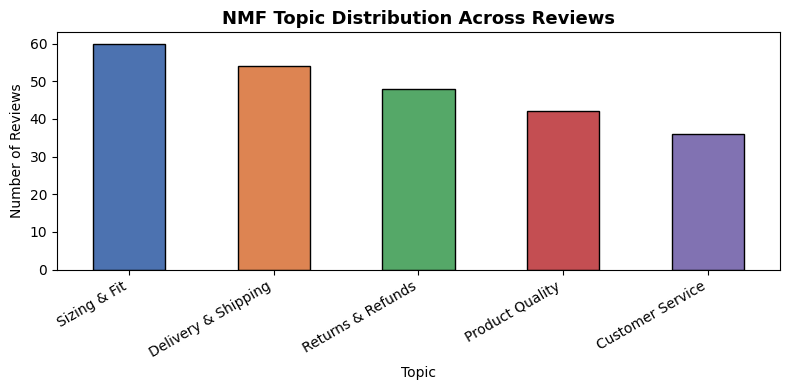

In [17]:
# Cell 16 – Topic distribution visualisation
plt.figure(figsize=(8,4))
topic_counts = df["topic_name"].value_counts()
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]
topic_counts.plot(kind="bar", color=colors, edgecolor="black")
plt.title("NMF Topic Distribution Across Reviews", fontsize=13, fontweight="bold")
plt.xlabel("Topic"); plt.ylabel("Number of Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("topic_dist.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# Cell 17 – Comprehensive evaluation comparison
models = {
    "VADER (Rule-Based)": (df["sentiment_label"], df["vader_pred"]),
    "LR Sentiment (TF-IDF)": (y_test, lr_preds),
    "LR Intent (TF-IDF)": (yi_test, intent_preds),
}

rows = []
for name, (y_true, y_pred) in models.items():
    rows.append({
        "Model": name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "F1 Score" : round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
    })

eval_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 65)
print("  COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("=" * 65)
print(eval_df.to_string())
print()
print("Most Suitable Metric: F1 Score (Weighted)")
print("  Reason: Customer reviews are class-imbalanced (more positive")
print("  reviews than complaints). F1 balances Precision & Recall,")
print("  making it more reliable than plain Accuracy in this scenario.")



  COMPREHENSIVE MODEL EVALUATION SUMMARY
                       Accuracy  Precision  Recall  F1 Score
Model                                                       
VADER (Rule-Based)        0.625      0.651   0.625    0.6303
LR Sentiment (TF-IDF)     1.000      1.000   1.000    1.0000
LR Intent (TF-IDF)        1.000      1.000   1.000    1.0000

Most Suitable Metric: F1 Score (Weighted)
  Reason: Customer reviews are class-imbalanced (more positive
  reviews than complaints). F1 balances Precision & Recall,
  making it more reliable than plain Accuracy in this scenario.


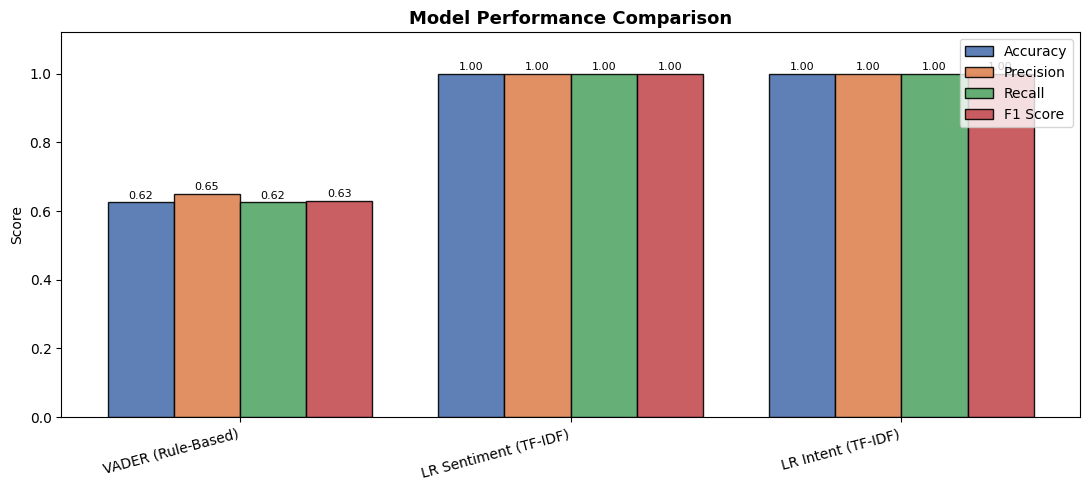

In [19]:
# Cell 18 – Visual metric comparison
eval_df_reset = eval_df.reset_index()
x = np.arange(len(eval_df_reset))
width = 0.2
metrics = ["Accuracy","Precision","Recall","F1 Score"]
colors  = ["#4C72B0","#DD8452","#55A868","#C44E52"]

fig, ax = plt.subplots(figsize=(11,5))
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + idx*width, eval_df_reset[metric], width,
                  label=metric, color=color, edgecolor="black", alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(eval_df_reset["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
# Cell 19 – Gradio Interface
import gradio as gr

def analyze_review(text):
    if not text.strip():
        return "Please enter a review.", "", ""

    # --- Sentiment (VADER rule-based) ---
    vs = analyzer.polarity_scores(text)["compound"]
    if vs >= 0.05:
        sentiment = f"😊 Positive  (VADER score: {vs:.3f})"
    elif vs <= -0.05:
        sentiment = f"😞 Negative  (VADER score: {vs:.3f})"
    else:
        sentiment = f"😐 Neutral   (VADER score: {vs:.3f})"

    # --- Sentiment (ML Logistic Regression) ---
    clean = preprocess(text)
    vec_s = tfidf_vec.transform([clean])
    ml_pred = lr_model.predict(vec_s)[0]
    ml_prob = lr_model.predict_proba(vec_s).max()
    sentiment += f"\n🤖 ML Prediction: {ml_pred} (confidence: {ml_prob:.2f})"

    # --- Intent ---
    vec_i = tfidf_i.transform([clean])
    intent = intent_model.predict(vec_i)[0]
    intent_prob = intent_model.predict_proba(vec_i).max()
    intent_out = f"🏷️ {intent}  (confidence: {intent_prob:.2f})"

    # --- Topic ---
    vec_t = tfidf_topic.transform([clean])
    topic_idx = nmf_model.transform(vec_t).argmax()
    topic_name = topic_labels[topic_idx]
    # Top keywords
    top_kw = [feature_names[j]
              for j in nmf_model.components_[topic_idx].argsort()[-8:][::-1]]
    topic_out = f"📌 {topic_name}\n🔑 Keywords: {', '.join(top_kw)}"

    return sentiment, intent_out, topic_out


demo = gr.Interface(
    fn=analyze_review,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type a customer review here (English or Roman Urdu)...",
        label="Customer Review"
    ),
    outputs=[
        gr.Textbox(label="Sentiment Analysis"),
        gr.Textbox(label="Intent Classification"),
        gr.Textbox(label="Topic & Keywords"),
    ],
    title="🛍️ Customer Reviews Intelligence System",
    description=(
        "Enter a customer review to get:\n"
        "• Sentiment (Rule-based VADER + ML Logistic Regression)\n"
        "• Intent (Complaint / Refund Request / Delivery Issue / General Query)\n"
        "• Dominant Topic with Key Keywords (NMF)"
    ),
    examples=[
        ["The dress is absolutely beautiful and fits perfectly!"],
        ["Worst product ever, I want a full refund immediately!"],
        ["My package has not arrived yet, delivery is very late."],
        ["Yeh product bohat ghatia hai, paisa wapas karo!"],
        ["Average quality, nothing special about this item."],
    ],
    theme="soft"
)

demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://65f5227b1bb9b097a8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
